In [8]:
from itertools import product
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams.update({
    "mathtext.fontset": "cm",   # Computer Modern
    "font.family": "serif"
})

import numpy as np

from solver import Solver

def driver(a1, a2, a3, etaf_guess, f_start = 1e-4, state_space=1):
    solver = Solver(a1, a2, a3, Q0, epsilon)
    return solver.find_etaf(etaf_guess,f_start=f_start, state_space=state_space, fp_condition=-10)

epsilon = 1
Q0 = 0.1

param_set = [
            [2, 1/4,   3/4],
            [4, 1/6,   5/6],
            [6, 1/8,   7/8],
            [8, 11/10, 9/10]
            ]


etaf_guess = 0.4
fstart = 1e-2

sols = []
for params in tqdm(param_set):
    a1, gamma, omega = params
    a2 = a3 = a1 + 1
    sols.append(driver(a1, a2, a3, etaf_guess=etaf_guess, f_start = fstart))
    print(sols[-1].a1, sols[-1].a2, sols[-1].a3, sols[-1].eta_f, sols[-1].x[0][0])

  0%|          | 0/4 [00:00<?, ?it/s]

0.4
0.40014
0.35587281718680114
0.35338693300396945
0.3532285054804608
0.3532279286451501


 25%|██▌       | 1/4 [00:25<01:16, 25.39s/it]

2 3 3 0.3530391929753442 0.41987476815452257
0.4
0.40014
0.22827677022814402
0.20876920943528562
0.2052690324419136
0.20517694824907426
0.20517655976127766


 50%|█████     | 2/4 [01:34<01:42, 51.15s/it]

4 5 5 0.20517654501794796 0.60775974049606
0.4
0.40014
0.18548446755373474
0.16579571791526182
0.16262137643638094
0.162552693940784
0.1625524762389875


 75%|███████▌  | 3/4 [03:40<01:25, 85.37s/it]

6 7 7 0.16255247580207804 0.71709064713348
0.4
0.40014
0.16428489790714987
0.1457259998186617
0.1431600757871837


 75%|███████▌  | 3/4 [04:43<01:34, 94.59s/it]


KeyboardInterrupt: 

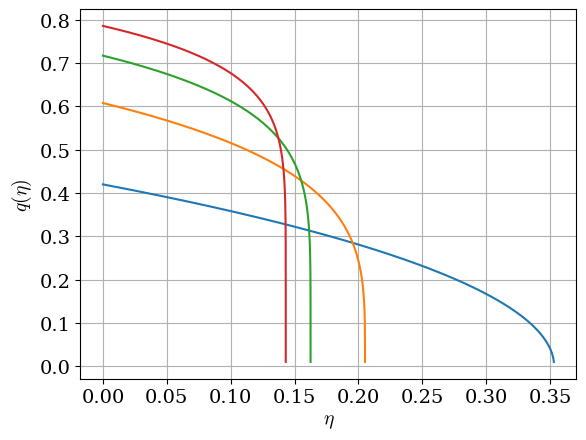

In [5]:
fig, ax = plt.subplots()
for sol,params in zip(sols, param_set):
    ax.plot(sol.eta, sol.x[0], label = "$\\alpha_1 = {}, \\gamma = {}, \\omega = {}$".format(*params))
    # ax.text(0, sol.x[0][0], "$f(0) = {:.4f}$".format(sol.x[0][0]))
    # ax.text(sol.eta[-1], fstart, "$\\eta_f = {:.4f}$".format(sol.eta_f))

ax.set_ylabel("$f(\\eta)$")
ax.set_ylabel("$q(\\eta)$")
ax.grid()
ax.set_xlabel("$\\eta$");


In [7]:
import pickle 
with open("sol1.pkl", 'wb') as f:
    pickle.dump(sols, f)
